In [1]:
%load_ext autoreload
%autoreload 2

from omegaconf import OmegaConf

OmegaConf.register_new_resolver(
    "relpath", lambda p: str(Path('/disk/scratch/nkudryas/BAND-torch/notebooks/').parent / p)
)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.linear_model import Ridge 
from sklearn.decomposition import PCA
import os

from lfads_torch.post_run.band_analysis import run_posterior_sampling

mkdir -p failed for path /afs/inf.ed.ac.uk/user/n/nkudryas/.config/matplotlib: [Errno 13] Permission denied: '/afs/inf.ed.ac.uk/user/n/nkudryas/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-zuezetig because there was an issue with the default path (/afs/inf.ed.ac.uk/user/n/nkudryas/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [3]:
os.environ['TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD'] = '1'

In [4]:
PATH = '/disk/scratch/nkudryas/BAND-torch/datasets'

model_titles = ["CSAE acausal (LFADS)", "BAND acausal", "CSAE causal", "BAND causal"]

bin_size_ms = 10

In [5]:
model_dests = []
model_names = []
n=8
for postfix in ['feedback_10','0','forward_10']:
    dataset_name = f'lorenz_{postfix}'
    this_model_names = [f'lfads_acausal_{n}f_lorenz', f'band_acausal_{n}f_lorenz', f'lfads_causal_{n}f_lorenz', f'band_causal_{n}f_lorenz']
    this_model_names = [model_name+'_'+postfix for model_name in this_model_names]
        
    best_model_dest = f"/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/{dataset_name}"
    model_dests = model_dests+[f"{best_model_dest}/{model_name}/best_model/" for model_name in this_model_names]
    model_names = model_names+this_model_names
    # models = [BAND(model_dir=model_dest) for model_dest in model_dests]

In [6]:
model_dests

['/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_feedback_10/lfads_acausal_8f_lorenz_feedback_10/best_model/',
 '/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_feedback_10/band_acausal_8f_lorenz_feedback_10/best_model/',
 '/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_feedback_10/lfads_causal_8f_lorenz_feedback_10/best_model/',
 '/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_feedback_10/band_causal_8f_lorenz_feedback_10/best_model/',
 '/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_0/lfads_acausal_8f_lorenz_0/best_model/',
 '/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_0/band_acausal_8f_lorenz_0/best_model/',
 '/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_0/lfads_causal_8f_lorenz_0/best_model/',
 '/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_0/band_causal_8f_lorenz_0/best_model/',
 '/disk/scratch/nkudryas

In [7]:
import torch
from hydra.utils import instantiate
from pathlib import Path
import hydra

from lfads_torch.band_utils import flatten

overrides={
        "datamodule": dataset_name,
        "model": 'lorenz'
    }
config_path="../../configs/single.yaml"
print(config_path)

# Compose the train config with properly formatted overrides
config_path = Path(config_path)
overrides = [f"{k}={v}" for k, v in flatten(overrides).items()]
with hydra.initialize(
    config_path=config_path.parent,
    job_name="get_weights",
    version_base="1.1",
):
    config = hydra.compose(config_name=config_path.name, overrides=overrides)

# Instantiate `LightningDataModule` and `LightningModule`
datamodule = instantiate(config.datamodule, _convert_="all")
model = instantiate(config.model)

# check the latest checkpoint
from glob import glob
checkpoint_folders = glob(model_dests[1]+'/checkpoint*')

ckpt_path = checkpoint_folders[-1] + '/tune.ckpt'
# f'{model_dests[1]}/lightning_checkpoints/last.ckpt'
model.load_state_dict(torch.load(ckpt_path)["state_dict"])

../../configs/single.yaml


/tmp/ipykernel_1397707/3968517386.py:35: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  model.load_state_dict(torch.load(ckpt_path)["state_dict"])


<All keys matched successfully>

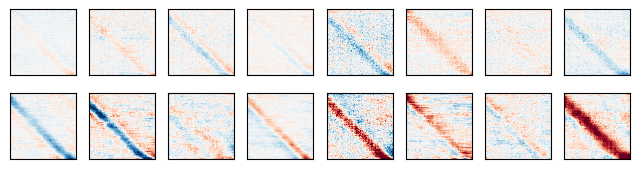

In [8]:
seq_len = config.model.recon_seq_len
in_features = config.model.fac_dim #config.model.behavior_readout.modules[0].in_features
out_features = config.model.behavior_readout.out_features
beh_W = model.behavior_readout.layers[2].weight.T

assert beh_W.shape == (in_features*seq_len, out_features*seq_len)

beh_W = beh_W.reshape((seq_len, in_features, seq_len, out_features))

r = torch.std(beh_W)*4
fig, ax = plt.subplots(out_features, in_features, figsize=(in_features, out_features))
for j in range(in_features):
    for i in range(out_features):
        ax[i,j].imshow(beh_W[:,j,:,i].detach().numpy(), cmap='RdBu', vmin=-r, vmax=r)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_feedback_10/lfads_acausal_8f_lorenz_feedback_10/best_model/
/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_feedback_10/band_acausal_8f_lorenz_feedback_10/best_model/
/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_feedback_10/lfads_causal_8f_lorenz_feedback_10/best_model/
/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_feedback_10/band_causal_8f_lorenz_feedback_10/best_model/
/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_0/lfads_acausal_8f_lorenz_0/best_model/
/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_0/band_acausal_8f_lorenz_0/best_model/


/tmp/ipykernel_1397707/3349247380.py:9: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  model.load_state_dict(torch.load(ckpt_path)["state_dict"])


/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_0/lfads_causal_8f_lorenz_0/best_model/
/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_0/band_causal_8f_lorenz_0/best_model/
/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_forward_10/lfads_acausal_8f_lorenz_forward_10/best_model/
/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_forward_10/band_acausal_8f_lorenz_forward_10/best_model/
/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_forward_10/lfads_causal_8f_lorenz_forward_10/best_model/
/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_forward_10/band_causal_8f_lorenz_forward_10/best_model/


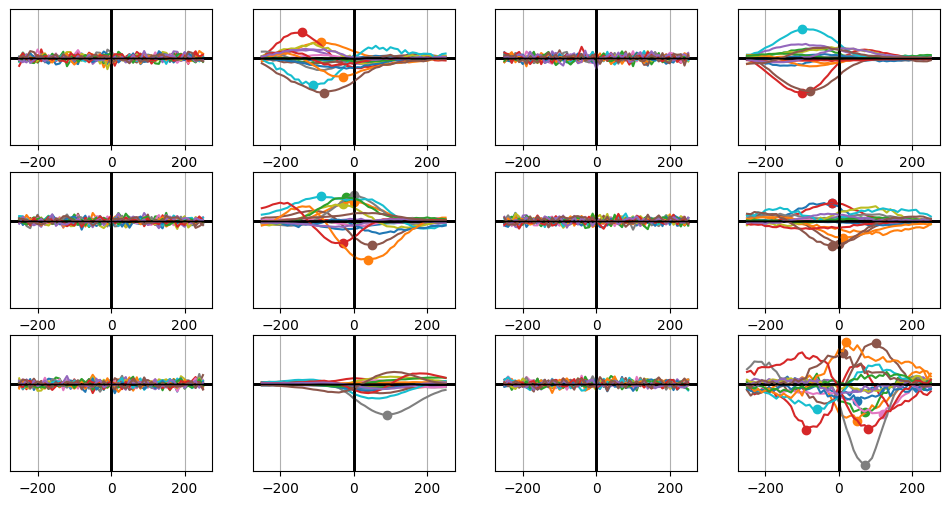

In [9]:
id_maxs = []
fig, axes = plt.subplots(3,4, figsize=(12,6),sharey=True)
ax = axes.flatten()
for mi, (model_name, model_dest) in enumerate(zip(model_names, model_dests)):
    # check the latest checkpoint
    checkpoint_folders = glob(model_dest+'/checkpoint*')
    print(model_dest)
    ckpt_path = checkpoint_folders[-1] + '/tune.ckpt'
    model.load_state_dict(torch.load(ckpt_path)["state_dict"])

    beh_W = model.behavior_readout.layers[2].weight.T
    assert beh_W.shape == (in_features*seq_len, out_features*seq_len)
    beh_W = beh_W.reshape((seq_len, in_features, seq_len, out_features))

    color_counter = 0
    for j in range(min(in_features,10)):
        for i in range(out_features):
            w = beh_W[:,j,:,i].detach().numpy()
            lags = np.arange(-25, 26)
            amp = np.zeros_like(lags, dtype=float)
            for k,lag in enumerate(lags):
                amp[k] = np.sum(np.diag(w, k=lag))
            ax[mi].plot(10*lags,amp)
            id_max = np.argmax(np.abs(amp))
            id_maxs.append(id_max)
            if amp[id_max]>1 or amp[id_max]<-1:
                ax[mi].scatter(10*lags[id_max], amp[id_max], c=f'C{color_counter}')
                
            ax[mi].axhline(0, color='k', linewidth=1)
            ax[mi].axvline(0, color='k', linewidth=1)
            ax[mi].set_yticks([])
            ax[mi].grid(True,which='both')
            color_counter += 1

In [10]:
model_titles

['CSAE acausal (LFADS)', 'BAND acausal', 'CSAE causal', 'BAND causal']

/tmp/ipykernel_1397707/2154373773.py:13: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  model.load_state_dict(torch.load(ckpt_path)["state_dict"])


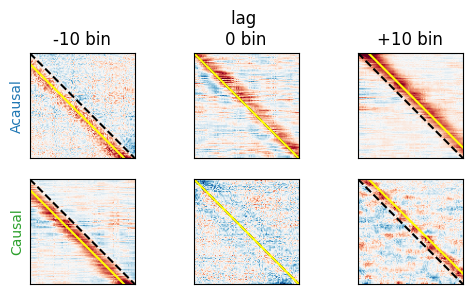

In [11]:
def plot_weights(axes,model_names, model_dests,color_code):

    mi = [0,0]
    for model_name, model_dest in zip(model_names, model_dests):
        if 'band' in model_name:
            if 'acausal' in model_name:
                row = 0
            else:
                row = 1
            # check the latest checkpoint
            checkpoint_folders = glob(model_dest+'/checkpoint*')
            ckpt_path = checkpoint_folders[-1] + '/tune.ckpt'
            model.load_state_dict(torch.load(ckpt_path)["state_dict"])

            beh_W = model.behavior_readout.layers[2].weight.T
            assert beh_W.shape == (in_features*seq_len, out_features*seq_len)
            beh_W = beh_W.reshape((seq_len, in_features, seq_len, out_features))

            SDs = np.zeros((out_features,in_features))
            for j in range(in_features):
                for i in range(out_features):
                    w = beh_W[:,j,:,i].detach().numpy()
                    SDs[i,j] = w.std()
            i,j = np.unravel_index(np.argmax(SDs, axis=None), SDs.shape)
            # i,j = 1,3 # happen to be high variance in all models
            w = beh_W[:,j,:,i].detach().numpy()
            r = np.std(w)*4

            axes[row,mi[row]].imshow(w, cmap='RdBu', vmin=-r, vmax=r)  
            mi[row] += 1

    for i,lag in enumerate([-10,0,10]):
        for j in [0,1]:
            axes[j,i].plot([0,seq_len-1], [0, seq_len-1], 'k--')
            axes[j,i].plot([0,seq_len-1+lag], [-lag, seq_len-1], color_code['input'])
            axes[j,i].set_xticks([])
            axes[j,i].set_yticks([])
            axes[j,i].set_xlim([0,seq_len-1])
            axes[j,i].set_ylim([seq_len-1,0])

    axes[0,0].set_title(' \n-10 bin')
    axes[0,1].set_title('lag \n0 bin')
    axes[0,2].set_title('\n+10 bin')
    axes[0,0].set_ylabel('Acausal',color = color_code['acausal'])
    axes[1,0].set_ylabel('Causal',color = color_code['causal'])

fig, axes = plt.subplots(2,3, figsize=(6,3),sharey=True)

color_code= {'causal': 'C2','acausal': 'C0','input': 'yellow'}
plot_weights(axes, model_names, model_dests,color_code)

/tmp/ipykernel_1397707/3246000045.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  model.load_state_dict(torch.load(ckpt_path)["state_dict"])


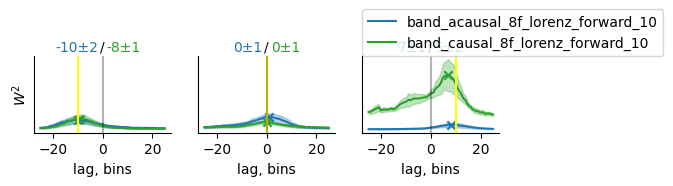

In [12]:
def plot_summary_lags(axes,model_names,model_dests,color_code):
    id_maxs = []
    plot_order = ['feedback','lorenz','forward']
    titles = [[None,None,None],[None,None,None]]
    for mi, (model_name, model_dest) in enumerate(zip(model_names, model_dests)):
        if 'band' in model_name:
            # check the latest checkpoint
            checkpoint_folders = glob(model_dest+'/checkpoint*')
            ckpt_path = checkpoint_folders[-1] + '/tune.ckpt'
            model.load_state_dict(torch.load(ckpt_path)["state_dict"])

            beh_W = model.behavior_readout.layers[2].weight.T
            assert beh_W.shape == (in_features*seq_len, out_features*seq_len)
            beh_W = beh_W.reshape((seq_len, in_features, seq_len, out_features))

            # bootstrap on factors
            amps = []
            for _ in range(1000):
                resample_factors = np.random.choice(in_features, size=in_features, replace=True)
                w = (beh_W[:,resample_factors].detach().numpy()**2).sum(-1).sum(1)
                lags = np.arange(-25, 26)
                amp = np.zeros_like(lags, dtype=float)
                for k,lag in enumerate(lags):
                    amp[k] = np.sum(np.diag(w, k=lag))
                amps.append(amp)
            amps = np.array(amps)

            postfix = model_name.split('_')[-2]
            ax_i = np.where(np.array(plot_order)==postfix)[0][0]
            ax = axes[ax_i]

            color = color_code['acausal'] if 'acausal' in model_name else color_code['causal']

            ax.plot(lags,amps.mean(0),label=model_name,c=color)
            ax.fill_between(lags, amps.mean(0)-amps.std(0), amps.mean(0)+amps.std(0), alpha=0.3,color=color)
            id_max = np.argmax(np.abs(amps.mean(0)))
            id_maxs.append(id_max)
            ax.scatter(lags[id_max], amps.mean(0)[id_max],c=color,marker='x')
            distr_args = np.argmax(amps,axis=-1)
            # print(f"{model_name}: {distr_args.mean()-25:6.2f}±{distr_args.std():6.2f}")
            titles[0 if 'acausal' in model_name else 1][ax_i] = f"{int(distr_args.mean()-25)}±{int(distr_args.std())}"
    # plt.legend()
    titles = np.array(titles).T
    for i,(lags,title) in enumerate(zip([-10,0,10],titles)):
        axes[i].axvline(lags,c=color_code['input'])
        axes[i].axvline(0,c='k',alpha=0.3)
        axes[i].set_xlabel('lag, bins')
        if i!=0:
            axes[i].set_yticks([])
        #remove right and top of the frame
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        # axes[i].set_title(fr'$\mathregular{{\color{{C0}}{{{title[0]}}}}}$ / $\mathregular{{\color{{C2}}{{{title[1]}}}}}$')
        # Turn off the standard title
        axes[i].set_title("")

        # Place the first part (aligned to the right of the center point)
        axes[i].text(0.47, 1.02, title[0], color=color_code['acausal'], 
                    transform=axes[i].transAxes, ha="right", va="bottom")

        # Place the divider
        axes[i].text(0.50, 1.02, "/", color="black", 
                    transform=axes[i].transAxes, ha="center", va="bottom")

        # Place the second part (aligned to the left of the center point)
        axes[i].text(0.53, 1.02, title[1], color=color_code['causal'], 
                    transform=axes[i].transAxes, ha="left", va="bottom")

    axes[0].set_ylabel(r'$W^2$')

plt.rcParams.update({'text.usetex': False})
fig, axes = plt.subplots(1,3, figsize=(6,1),sharey=True)

plot_summary_lags(axes,model_names,model_dests,color_code)
plt.legend(loc=(0,1))

In [13]:
# model.eval()
# # zero out weight
# B = torch.zeros_like(model.decoder.rnn.cell.co_linear.bias)
# B[len(B) // 2:] = -10 # making variance exp(-10)
# model.decoder.rnn.cell.co_linear.weight = torch.nn.Parameter(torch.zeros_like(model.decoder.rnn.cell.co_linear.weight))
# model.decoder.rnn.cell.co_linear.bias = torch.nn.Parameter(B)

# filename = model_dests[1] + '/lfads_ablated_output.h5'
# run_posterior_sampling(model, datamodule, filename, num_samples=50)

# Evaluate perturbed vs unperturbed trials

In [15]:
postfix='0'
dataset_filename = f'/disk/scratch/nkudryas/BAND-torch/datasets/data_Synthetic_Lorenz_behrel_off5_{postfix}.h5'

with h5py.File(dataset_filename, 'r') as f:
    print(f.keys())
    train_data = f['train_recon_data'][:]
    valid_data = f['valid_recon_data'][:]
    # train_inds, valid_inds = f["train_inds"][:], f["valid_inds"][:]
    valid_epoch = f["valid_epoch"][:]
    true_train_beh = f['train_behavior'][:]
    true_valid_beh = f['valid_behavior'][:]
    valid_latents = f['valid_true_latents'][:]
    true_valid_inputs = f['valid_true_inputs'][:]
    valid_is_perturbed = np.any(np.any(true_valid_inputs != 0,axis=1),axis=1)


postfix='feedback_10'
dataset_filename = f'/disk/scratch/nkudryas/BAND-torch/datasets/data_Synthetic_Lorenz_behrel_off5_{postfix}.h5'
with h5py.File(dataset_filename, 'r') as f:
    true_valid_inputs_feedback = f['valid_true_inputs'][:]
    true_valid_beh_feedback = f['valid_behavior'][:]
    true_valid_inputs_feedback = f['valid_true_inputs'][:]
    valid_is_perturbed_feedback = np.any(np.any(true_valid_inputs_feedback != 0,axis=1),axis=1)

<KeysViewHDF5 ['params', 'train_behavior', 'train_encod_data', 'train_epoch', 'train_recon_data', 'train_true_inputs', 'train_true_latents', 'valid_behavior', 'valid_encod_data', 'valid_epoch', 'valid_recon_data', 'valid_true_inputs', 'valid_true_latents']>


In [16]:
model_dests

['/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_feedback_10/lfads_acausal_8f_lorenz_feedback_10/best_model/',
 '/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_feedback_10/band_acausal_8f_lorenz_feedback_10/best_model/',
 '/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_feedback_10/lfads_causal_8f_lorenz_feedback_10/best_model/',
 '/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_feedback_10/band_causal_8f_lorenz_feedback_10/best_model/',
 '/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_0/lfads_acausal_8f_lorenz_0/best_model/',
 '/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_0/band_acausal_8f_lorenz_0/best_model/',
 '/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_0/lfads_causal_8f_lorenz_0/best_model/',
 '/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz_behrel_off5/lorenz_0/band_causal_8f_lorenz_0/best_model/',
 '/disk/scratch/nkudryas

In [17]:
def merge_train_valid(train_data, valid_data, train_inds, valid_inds):
    n_samples = len(train_data) + len(valid_data)
    merged_data = np.full((n_samples, *train_data.shape[1:]), np.nan)
    merged_data[train_inds] = train_data
    merged_data[valid_inds] = valid_data
    return merged_data

# Get the paths to all data files
both_factors = []
both_behaviors = []
both_behaviors_abl = []
both_controls = []
both_control_means = []
both_control_stds = []
both_rates = []
both_noci_rates = []
both_behaviors = []
lin_decoded_behs = []
lin_decoded_behs_abl = []
seq2seq_decoded_behs = []
seq2seq_decoded_behs_abl = []
beh_Ws_post = []
for model_name,model_dest in zip(model_names, model_dests):

    postfix = model_name.split('_')[-1]
    if postfix == 'lorenz':
        postfix = 'forward'
    data_path = os.path.join(model_dest,f'lfads_output_{postfix}.h5')
    bin_width_sec = 0.01 # chewie
    # Data is binned at 10 ms
    with h5py.File(data_path) as f:
        print(f.keys())
        # Merge train and valid data for factors and rates
        # train_inds, valid_inds = f["train_inds"][:], f["valid_inds"][:]
        factors = f["valid_factors"][:]
        beh = f['valid_output_behavior_params'][:]
        rates = f["valid_output_params"][:] / bin_width_sec
        controls = f['valid_gen_inputs'][:]
        ic = f['valid_gen_init'][:]
        control_mean = f['valid_co_means'][:]
        control_stds = f['valid_co_stds'][:]

        train_factors = f["train_factors"][:]
        train_controls = f['train_gen_inputs'][:]
        train_ic = f['train_gen_init'][:]

    # load ablated
    data_path = os.path.join(model_dest,f'lfads_W_ablated_output_{postfix}.h5')
    with h5py.File(data_path) as f:
        train_noci_factors = f["train_factors"][:]
        noci_factors = f["valid_factors"][:]
        noci_rates = f["valid_output_params"][:] / bin_width_sec
        beh_abl = f['valid_output_behavior_params'][:]
    
    # train Ridge regression to predict behavior from factors (0lag)
    X_train = train_factors.reshape(-1,train_factors.shape[-1])
    Y_train = true_train_beh.reshape(-1,true_train_beh.shape[-1])
    X_test = factors.reshape(-1,factors.shape[-1])
    ridge = Ridge(alpha=1).fit(X_train, Y_train)
    Y_pred_0lag = ridge.predict(X_test).reshape(true_valid_beh.shape)

    X_train = train_noci_factors.reshape(-1,train_noci_factors.shape[-1])
    Y_train = true_train_beh.reshape(-1,true_train_beh.shape[-1])
    X_test = noci_factors.reshape(-1,noci_factors.shape[-1])
    ridge = Ridge(alpha=1).fit(X_train, Y_train)
    Y_pred_0lag_abl = ridge.predict(X_test).reshape(true_valid_beh.shape)

    # Ridge seq2seq
    X_train = train_factors.reshape(train_factors.shape[0],-1)
    Y_train = true_train_beh.reshape(true_train_beh.shape[0],-1)
    X_test = factors.reshape(factors.shape[0],-1)
    # X_test_abl = noci_factors.reshape(noci_factors.shape[0],-1)
    ridge = Ridge(alpha=1).fit(X_train, Y_train)
    Y_pred_seq2seq = ridge.predict(X_test).reshape(true_valid_beh.shape)
    beh_Ws_post.append(ridge.coef_)
    # Y_pred_seq2seq_abl = ridge.predict(X_test_abl).reshape(true_valid_beh.shape)

    # same after ablating the controller
    X_train = train_noci_factors.reshape(train_noci_factors.shape[0],-1)
    Y_train = true_train_beh.reshape(true_train_beh.shape[0],-1)
    X_test = noci_factors.reshape(noci_factors.shape[0],-1)
    ridge = Ridge(alpha=1).fit(X_train, Y_train)
    Y_pred_seq2seq_abl = ridge.predict(X_test).reshape(true_valid_beh.shape)
            
    both_factors.append(factors)
    both_behaviors.append(beh)
    both_behaviors_abl.append(beh_abl)
    both_rates.append(rates)
    both_noci_rates.append(noci_rates) 
    both_controls.append(controls)
    both_control_means.append(control_mean)
    both_control_stds.append(control_stds)
    lin_decoded_behs.append(Y_pred_0lag)
    lin_decoded_behs_abl.append(Y_pred_0lag_abl)
    seq2seq_decoded_behs.append(Y_pred_seq2seq)
    seq2seq_decoded_behs_abl.append(Y_pred_seq2seq_abl)


<KeysViewHDF5 ['params', 'train_behavior', 'train_co_means', 'train_co_stds', 'train_con_states', 'train_encod_data', 'train_epoch', 'train_factors', 'train_gen_init', 'train_gen_inputs', 'train_gen_states', 'train_ic_mean', 'train_ic_std', 'train_output_behavior_params', 'train_output_params', 'train_recon_data', 'train_true_inputs', 'train_true_latents', 'valid_behavior', 'valid_co_means', 'valid_co_stds', 'valid_con_states', 'valid_encod_data', 'valid_epoch', 'valid_factors', 'valid_gen_init', 'valid_gen_inputs', 'valid_gen_states', 'valid_ic_mean', 'valid_ic_std', 'valid_output_behavior_params', 'valid_output_params', 'valid_recon_data', 'valid_true_inputs', 'valid_true_latents']>
<KeysViewHDF5 ['params', 'train_behavior', 'train_co_means', 'train_co_stds', 'train_con_states', 'train_encod_data', 'train_epoch', 'train_factors', 'train_gen_init', 'train_gen_inputs', 'train_gen_states', 'train_ic_mean', 'train_ic_std', 'train_output_behavior_params', 'train_output_params', 'train_rec

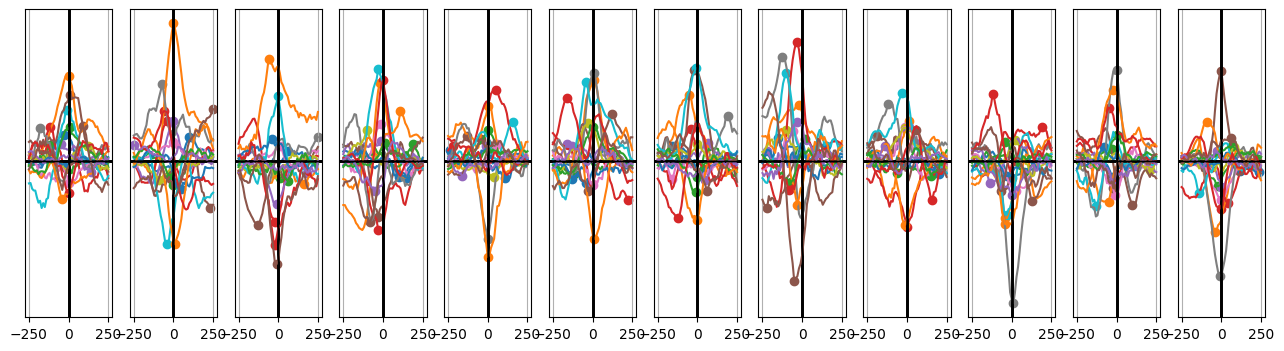

In [18]:
id_maxs = []
fig, ax = plt.subplots(1,len(model_names), figsize=(2*min(in_features,10), 2*out_features),sharey=True)
for mi, (model_name, model_dest) in enumerate(zip(model_names, model_dests)):
    beh_W = beh_Ws_post[mi].T
    assert beh_W.shape == (in_features*seq_len, out_features*seq_len)
    beh_W = beh_W.reshape((seq_len, in_features, seq_len, out_features))
    for j in range(min(in_features,10)):
        for i in range(out_features):
            w = beh_W[:,j,:,i]
            lags = np.arange(-25, 26)
            amp = np.zeros_like(lags, dtype=float)
            for k,lag in enumerate(lags):
                amp[k] = np.sum(np.diag(w, k=lag))
            ax[mi].plot(10*lags,amp)
            id_max = np.argmax(np.abs(amp))
            id_maxs.append(id_max)
            ax[mi].scatter(10*lags[id_max], amp[id_max])
                
            ax[mi].axhline(0, color='k', linewidth=1)
            ax[mi].axvline(0, color='k', linewidth=1)
            ax[mi].set_yticks([])
            ax[mi].grid(True,which='both')

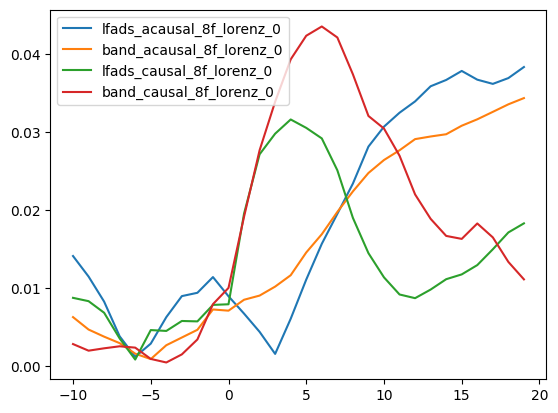

In [19]:
from utils import input_norm_around_stim, r2_score

t_before, t_after = 10,20
time_axis = np.arange(-t_before,t_after)
kick_idxs = [list(np.where(input)[0]) for input in true_valid_inputs.sum(-1)]
for i in range(0,4):
    plt.plot(time_axis, input_norm_around_stim(both_control_means[i+4], kick_idxs, t_before=10, t_after=20),label=model_names[i+4])
plt.legend()

0
band_acausal_8f_lorenz_feedback_10:  -0.16+-  1.02
0
band_causal_8f_lorenz_feedback_10:   0.00+-  0.00
1
band_acausal_8f_lorenz_0:   0.22+-  1.20
1
band_causal_8f_lorenz_0:  -0.67+-  1.54
2
band_acausal_8f_lorenz_forward_10:   0.09+-  0.45
2
band_causal_8f_lorenz_forward_10:   0.00+-  0.00


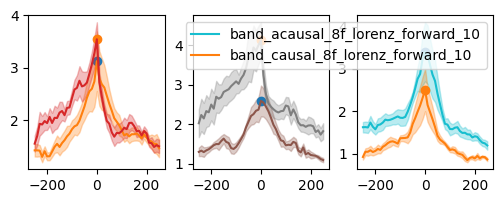

In [20]:
fig, axes = plt.subplots(1,3, figsize=(6,2))

id_maxs = []
plot_order = ['feedback','lorenz','forward']
for mi, (model_name, model_dest) in enumerate(zip(model_names, model_dests)):
    if 'band' in model_name:
        beh_W = beh_Ws_post[mi].T
        assert beh_W.shape == (in_features*seq_len, out_features*seq_len)
        beh_W = beh_W.reshape((seq_len, in_features, seq_len, out_features))

        # bootstrap on factors
        amps = []
        for _ in range(100):
            resample_factors = np.random.choice(in_features, size=in_features, replace=True)
            w = (beh_W[:,resample_factors]**2).sum(-1).sum(1)
            lags = np.arange(-25, 26)
            amp = np.zeros_like(lags, dtype=float)
            for k,lag in enumerate(lags):
                amp[k] = np.sum(np.diag(w, k=lag))
            amps.append(amp)
        amps = np.array(amps)

        postfix = model_name.split('_')[-2]
        ax_i = np.where(np.array(plot_order)==postfix)[0][0]
        print(ax_i)
        ax = axes[ax_i]

        ax.plot(10*lags,amps.mean(0),label=model_name,c=f'C{mi}')
        ax.fill_between(10*lags, amps.mean(0)-amps.std(0), amps.mean(0)+amps.std(0), alpha=0.3,color=f'C{mi}')
        id_max = np.argmax(np.abs(amps.mean(0)))
        id_maxs.append(id_max)
        ax.scatter(10*lags[id_max], amps.mean(0)[id_max])
        distr_args = np.argmax(amps,axis=-1)
        print(f"{model_name}: {distr_args.mean()-25:6.2f}+-{distr_args.std():6.2f}")
plt.legend()

Text(0.5, 1.0, 'Behavior decoding R2 from factors: Ablated vs Non-ablated')

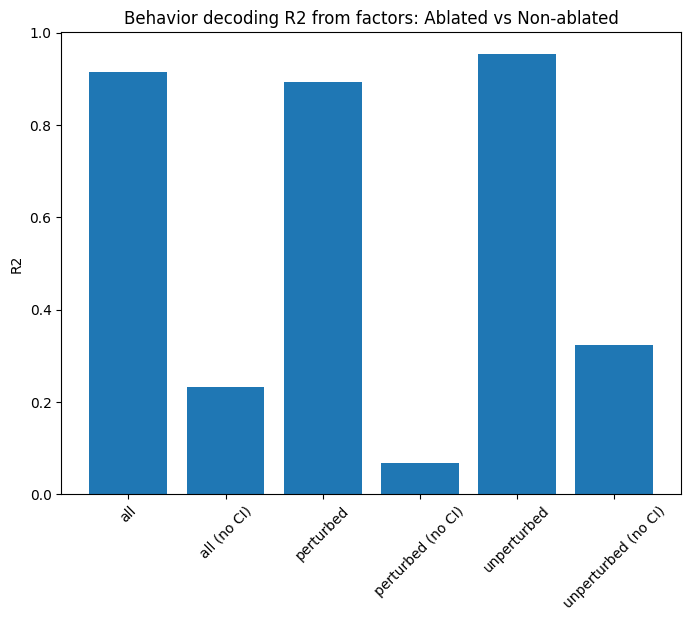

In [21]:
# compute behavior seq2seq R2 for perturbed vs unperturbed trials, ablated vs non-ablated; plot a bar plot
# valid_set['is_perturbed']
from lfads_torch.metrics import r2_score
plt.figure(figsize=(8,6))

model_id = 1 # 0 -- LFADS, 1 -- BAND
Y_pred, Y_pred_abl = seq2seq_decoded_behs[model_id], seq2seq_decoded_behs_abl[model_id]
# Y_pred, Y_pred_abl = lin_decoded_behs[model_id], lin_decoded_behs_abl[model_id]
plt.bar(['all', 'all (no CI)','perturbed','perturbed (no CI)', 'unperturbed', 'unperturbed (no CI)'], 
        
                                            [r2_score(true_valid_beh, Y_pred_seq2seq), 
                                                        r2_score(true_valid_beh, Y_pred_abl),
                                            r2_score(true_valid_beh[valid_is_perturbed], 
                                                     Y_pred[valid_is_perturbed]), 
                                            r2_score(true_valid_beh[valid_is_perturbed], 
                                                     Y_pred_abl[valid_is_perturbed]),
                                            r2_score(true_valid_beh[~valid_is_perturbed], 
                                                     Y_pred[~valid_is_perturbed]), 
                                            r2_score(true_valid_beh[~valid_is_perturbed], 
                                                     Y_pred_abl[~valid_is_perturbed])])
# rotate labels by 45 degrees
plt.xticks(rotation=45)
plt.ylabel('R2')
plt.title('Behavior decoding R2 from factors: Ablated vs Non-ablated')

Text(0.5, 1.0, 'BPS: Ablated vs Non-ablated')

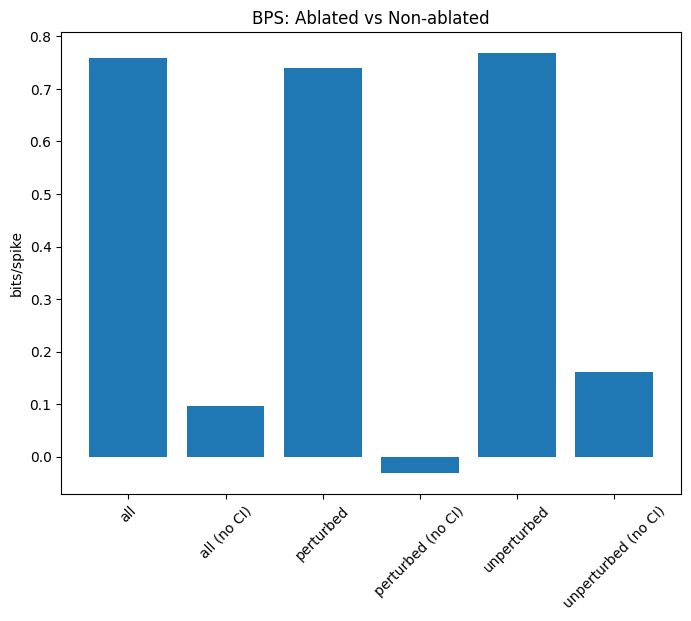

In [22]:
# now same but for NLL
from scipy.stats import poisson
plt.figure(figsize=(8,6))
model_id = 3 # 0 -- LFADS, 1 -- BAND
rates, noci_rates = both_rates[model_id] * bin_width_sec, both_noci_rates[model_id] * bin_width_sec

valid_mean_count = valid_data.mean(0).mean(0) # to get Hz -> x100
base_LL = poisson.logpmf(valid_data, valid_mean_count)
n_sp = valid_data.sum()
# print(base_LL.mean(),poisson.logpmf(valid_data, rates).mean())
# print(np.nansum(poisson.logpmf(valid_data, rates) - base_LL)/(n_sp * np.log(2)))

plt.bar(['all', 'all (no CI)','perturbed','perturbed (no CI)', 'unperturbed', 'unperturbed (no CI)'],
        [np.nansum(poisson.logpmf(valid_data, rates) - base_LL)/(n_sp * np.log(2)),
                np.nansum(poisson.logpmf(valid_data, noci_rates) - base_LL)/(n_sp * np.log(2)),
                np.nansum(poisson.logpmf(valid_data[valid_is_perturbed], rates[valid_is_perturbed]) - base_LL[valid_is_perturbed])/(valid_data[valid_is_perturbed].sum() * np.log(2)),
                np.nansum(poisson.logpmf(valid_data[valid_is_perturbed], noci_rates[valid_is_perturbed]) - base_LL[valid_is_perturbed])/(valid_data[valid_is_perturbed].sum() * np.log(2)),
                np.nansum(poisson.logpmf(valid_data[~valid_is_perturbed], rates[~valid_is_perturbed]) - base_LL[~valid_is_perturbed])/(valid_data[~valid_is_perturbed].sum() * np.log(2)),
                np.nansum(poisson.logpmf(valid_data[~valid_is_perturbed], noci_rates[~valid_is_perturbed]) - base_LL[~valid_is_perturbed])/(valid_data[~valid_is_perturbed].sum() * np.log(2))])
plt.xticks(rotation=45)
plt.ylabel('bits/spike')
plt.title('BPS: Ablated vs Non-ablated')

# Run on test

In [23]:
# config.datamodule.datafile_pattern = config.datamodule.datafile_pattern.split('.h5')[0] + '_test.h5'
# config.model.ic_enc_seq_len = 0
# config.model.causal_con = False
# datamodule_test = instantiate(config.datamodule, _convert_="all")

# for md,mn in zip(model_dests,model_names):
#     model = instantiate(config.model)
#     # check the latest checkpoint
#     checkpoint_folders = glob(md+'/checkpoint*')

#     ckpt_path = checkpoint_folders[-1] + '/tune.ckpt'
#     # f'{model_dests[1]}/lightning_checkpoints/last.ckpt'
#     model.load_state_dict(torch.load(ckpt_path)["state_dict"])
   
#     filename = md + f'/{mn}_test_adaptation.h5'
#     run_posterior_sampling(model, datamodule_test, filename, num_samples=50)

# bits and pieces for a mega-figure

In [24]:
np.where(true_valid_inputs[17].sum(-1)!=0)

(array([13, 41, 43, 54, 65, 79, 89]),)

In [25]:
np.where(true_valid_inputs.sum(-1)!=0)

(array([  1,   1,   1,   1,   1,   1,   1,   1,   4,   4,   4,   4,  10,
         10,  10,  10,  14,  14,  14,  14,  17,  17,  17,  17,  17,  17,
         17,  21,  21,  21,  21,  21,  21,  24,  30,  30,  34,  34,  34,
         34,  34,  34,  34,  36,  36,  36,  38,  38,  38,  38,  38,  38,
         39,  39,  39,  39,  39,  39,  39,  39,  41,  41,  41,  41,  41,
         41,  46,  46,  46,  48,  48,  48,  48,  48,  48,  48,  48,  51,
         51,  51,  51,  55,  55,  55,  55,  55,  57,  57,  57,  57,  57,
         59,  59,  59,  59,  59,  59,  59,  59,  59,  60,  60,  60,  60,
         62,  62,  62,  62,  62,  62,  62,  62,  63,  63,  63,  63,  63,
         63,  63,  63,  64,  64,  64,  64,  64,  64,  67,  67,  67,  67,
         75,  75,  75,  75,  75,  78,  78,  78,  78,  86,  86,  86,  88,
         88,  89,  89,  89,  89,  92,  92,  92,  97,  97,  98,  98,  99,
         99,  99,  99,  99, 104, 104, 104, 108, 108, 108, 108, 111, 111,
        111, 113, 113, 113, 116, 116, 116, 116, 116

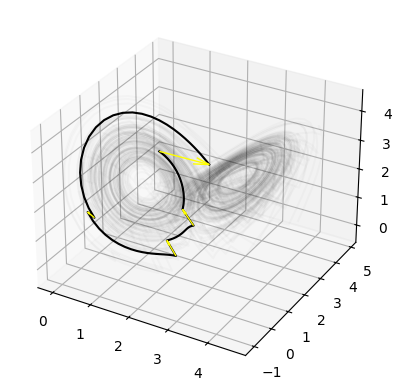

In [26]:
def plot_3D_trajectory(ax, z_true, inputs, color_code, trials2plot=[0]):
    n_trials, n_time_bins, _ = z_true.shape
    for i in trials2plot:
        ax.plot(z_true[i, :, 0], z_true[i, :, 1], z_true[i, :, 2],color='k')
        kick_t = np.where(inputs[i].sum(-1)!=0)[0]
        for t in kick_t:
            origin = z_true[i,t]
            # vector = -inputs[i,t]*.1
            vector = z_true[i,t-1] - z_true[i,t]
            ax.quiver(origin[0], origin[1], origin[2],
                vector[0], vector[1], vector[2],
                color=color_code['input'], length=1.0, linewidth=1, normalize=False) 
    for i in range(200):
        ax.plot(z_true[i, :, 0], z_true[i, :, 1], z_true[i, :, 2],color='k',alpha=0.02)

fig = plt.figure()
# create 3D axis
axis = fig.add_subplot(111, projection='3d')
plot_3D_trajectory(axis, valid_latents,true_valid_inputs, color_code, trials2plot=[4])

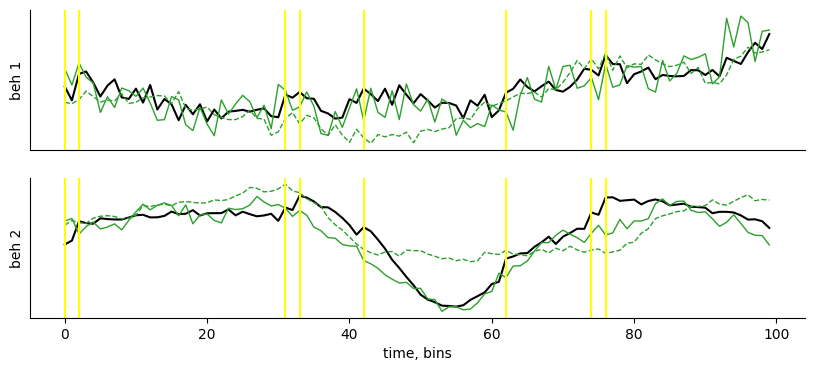

In [27]:
def plot_behavior_prediction(axes,true_beh,pred_beh,inputs,color_code,trials2plot=[0],linestyles=None):
    assert len(axes) == true_beh.shape[-1], 'Number of axes does not match beh components'

    if linestyles is None:
        linestyles = ['solid' for _ in pred_beh]
    for i in range(len(axes)):
        for t in trials2plot:
            axes[i].plot(true_beh[t,:,i],c='k')
            for pb,ls in zip(pred_beh,linestyles):
                axes[i].plot(pb[t,:,i],c=color_code['causal'],linestyle=ls,lw=1)
            kick_t = np.where(inputs[t].sum(-1)!=0)[0]
            for kt in kick_t:
                axes[i].axvline(kt,c=color_code['input'])

        if i!=(len(axes)-1):
            axes[i].set_xticks([])
        else:
            axes[i].set_xlabel('time, bins')
        axes[i].set_ylabel(f'beh {i+1}')
        axes[i].set_yticks([])
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
fig,axes = plt.subplots(2,figsize=(10,4))   
# plot_behavior_prediction(axes,true_valid_beh,[both_behaviors[1+4],both_behaviors[3+4]],true_valid_inputs,trials2plot=[12]) 
plot_behavior_prediction(axes,true_valid_beh,[seq2seq_decoded_behs[3+4],seq2seq_decoded_behs_abl[3+4]],true_valid_inputs,color_code,trials2plot=[1],linestyles=['solid','dashed']) 


# Print-ready figure

In [28]:
model_names

['lfads_acausal_8f_lorenz_feedback_10',
 'band_acausal_8f_lorenz_feedback_10',
 'lfads_causal_8f_lorenz_feedback_10',
 'band_causal_8f_lorenz_feedback_10',
 'lfads_acausal_8f_lorenz_0',
 'band_acausal_8f_lorenz_0',
 'lfads_causal_8f_lorenz_0',
 'band_causal_8f_lorenz_0',
 'lfads_acausal_8f_lorenz_forward_10',
 'band_acausal_8f_lorenz_forward_10',
 'lfads_causal_8f_lorenz_forward_10',
 'band_causal_8f_lorenz_forward_10']

In [29]:
os.chdir('../paper')
from goodman_panels import panels, panel_specs, label_panel, label_panels
os.chdir('../post')

/tmp/ipykernel_1397707/2154373773.py:13: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  model.load_state_dict(torch.load(ckpt_path)["state_dict"])
/tmp/ipykernel_1397707/3246000045.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  model.load_state_dict(torch.load(ckpt_path)["state_dict"])


[0.88853264, 0.1745837, 0, 0.95752156, 0.5126698]
[0.87504095, 0.47264656, 0, 0.949049, 0.7474239]


/tmp/ipykernel_1397707/2103606249.py:143: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[letter].set_xticklabels(labels, rotation=90, fontsize=8)
/tmp/ipykernel_1397707/2103606249.py:143: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[letter].set_xticklabels(labels, rotation=90, fontsize=8)


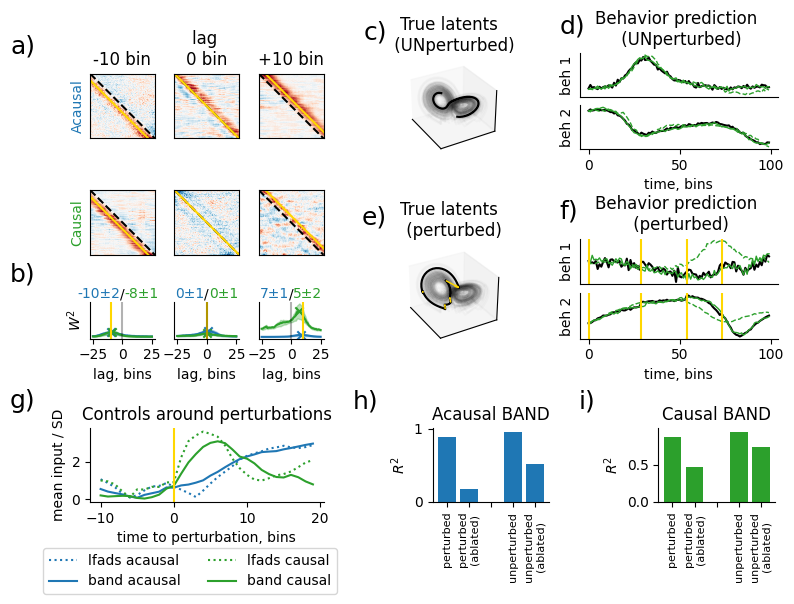

<Figure size 800x600 with 0 Axes>

In [31]:
layout = '''
ACD
A..
AEF
BEF
...
GHI
'''

color_code= {'causal': 'C2','acausal': 'C0','input': 'gold'}

cm = 1/2.54  # centimeters in inches
fig = plt.figure(figsize=(20*cm, 15*cm))
# blank = fig.add_subplot([0,0,1,1])
specs, gs = panel_specs(layout, fig=fig, gridspec_args={'left': 0.1, 'right': .97, 'bottom': 0.16, 'top': 0.92, 'hspace': .5, 'wspace': .7})

gs.set_width_ratios([2,1,1])
gs.set_height_ratios([1.3,0.5,.5,.5,0.5,1])

axes = {}
subgs = specs['A'].subgridspec(2, 3, wspace=0.3, hspace=0.1)
axes['A'] = []
for j in range(2):
    for i in range(3):
        if j == 0:
            axes[f"A{j}{i}"] = ax = fig.add_subplot(subgs[j,i])
        else:
            axes[f'A{j}{i}'] = ax = fig.add_subplot(subgs[j,i], sharey=axes[f'A0{i}'])
axes['A'] = np.array([[axes[f'A{j}{i}'] for j in range(2)] for i in range(3)]).T
label_panel(axes['A00'], 'a', postfix=')')

subgs = specs['B'].subgridspec(1, 3, wspace=0.3, hspace=0.1)
axes['B'] = []
for i in range(3):
    if i ==0 :
        axes[f"B{i}"] = ax = fig.add_subplot(subgs[i])
    else:
        axes[f"B{i}"] = ax = fig.add_subplot(subgs[i],sharey=axes['B0'])
axes['B'] = np.array([axes[f'B{i}'] for i in range(3)])
label_panel(axes['B0'], 'b', postfix=')')

axes['C'] = ax = fig.add_subplot(specs['C'], projection='3d')
ax.view_init(elev=30, azim=-30)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
p = ax.get_position()
ax.set_position([p.x0-0.05, p.y0-0.01, p.width, p.height])
label_panel(ax, 'c',offset_left=.4, postfix=')')

subgs = specs['D'].subgridspec(2, 1)
axes['D'] = []
for i in range(2):
    axes[f"D{i}"] = ax = fig.add_subplot(subgs[i])
#     # manually move up
    p = ax.get_position()
    ax.set_position([p.x0-0.1, p.y0, p.width*1.7, p.height])
    axes['D'].append(ax)
label_panel(axes['D0'], 'd', offset_left=0.2,postfix=')')

axes['E'] = ax = fig.add_subplot(specs['E'], projection='3d')
ax.view_init(elev=30, azim=-30)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
p = ax.get_position()
ax.set_position([p.x0-0.05, p.y0-0.01, p.width, p.height])
label_panel(ax, 'e',offset_left=.4, postfix=')')

subgs = specs['F'].subgridspec(2, 1)
axes['F'] = []
for i in range(2):
    axes[f"F{i}"] = ax = fig.add_subplot(subgs[i])
#     # manually move up
    p = ax.get_position()
    ax.set_position([p.x0-0.1, p.y0, p.width*1.7, p.height])
    axes['F'].append(ax)
label_panel(axes['F0'], 'f', offset_left=0.2,postfix=')')


# true_valid_beh

for letter in 'GHI':
    axes[letter] = ax = fig.add_subplot(specs[letter])
    label_panel(ax, letter.lower(),postfix=')')


plot_weights(axes['A'], model_names, model_dests,color_code)
plot_summary_lags(axes['B'],model_names,model_dests,color_code)

trials2plot=[5]
plot_3D_trajectory(axes['C'], valid_latents, true_valid_inputs, color_code, trials2plot=trials2plot)
plot_behavior_prediction(axes['D'],true_valid_beh,[seq2seq_decoded_behs[3+4],seq2seq_decoded_behs_abl[3+4]], true_valid_inputs,color_code,trials2plot=trials2plot,linestyles=['solid','dashed']) 
axes['C'].set_title('True latents \n (UNperturbed)')
axes['D0'].set_title('Behavior prediction \n (UNperturbed)')

trials2plot=[4]
plot_3D_trajectory(axes['E'], valid_latents, true_valid_inputs, color_code, trials2plot=trials2plot)
plot_behavior_prediction(axes['F'],true_valid_beh,[seq2seq_decoded_behs[3+4],seq2seq_decoded_behs_abl[3+4]], true_valid_inputs,color_code,trials2plot=trials2plot,linestyles=['solid','dashed']) 
axes['E'].set_title('True latents \n (perturbed)')
axes['F0'].set_title('Behavior prediction \n (perturbed)')

t_before, t_after = 10,20
time_axis = np.arange(-t_before,t_after)
kick_idxs = [list(np.where(input)[0]) for input in true_valid_inputs_feedback.sum(-1)]
for i in range(4,8):
    causality = model_names[i].split('_')[1]=='causal'
    title = model_names[i].split('_')[0] + (' causal' if causality else ' acausal')
    input = input_norm_around_stim(both_control_means[i], kick_idxs, t_before=10, t_after=20)
    input /= input.std()
    axes['G'].plot(time_axis, input,label=title,c=color_code['causal' if causality else 'acausal'],linestyle='solid' if 'band' in model_names[i] else 'dotted')
axes['G'].axvline(0,c=color_code['input'])
axes['G'].legend(loc=(-.2,-1.25),ncol=2)
axes['G'].set_xlabel('time to perturbation, bins')
axes['G'].set_ylabel('mean input / SD')
axes['G'].set_title('Controls around perturbations')
axes['G'].spines['top'].set_visible(False)
axes['G'].spines['right'].set_visible(False)

# compute behavior seq2seq R2 for perturbed vs unperturbed trials, ablated vs non-ablated; plot a bar plot
# valid_set['is_perturbed']
from lfads_torch.metrics import r2_score
plt.figure(figsize=(8,6))

# model_id = 3 # 0 -- LFADS, 1 -- BAND; first 4 -- feedback, next 4 -- 0 lag, next 4 -- forward
labels = ['perturbed','perturbed\n(ablated)', '', 'unperturbed', 'unperturbed\n(ablated)']
for letter, model_id, code in zip(['H','I'],[1+4,3+4],['acausal','causal']):
    # Y_pred, Y_pred_abl = both_behaviors[model_id], both_behaviors_abl[model_id]
    Y_pred, Y_pred_abl = seq2seq_decoded_behs[model_id], seq2seq_decoded_behs_abl[model_id]
    # Y_pred, Y_pred_abl = lin_decoded_behs[model_id], lin_decoded_behs_abl[model_id]

    R2s = [r2_score(true_valid_beh[valid_is_perturbed], 
                                                        Y_pred[valid_is_perturbed]), 
                                                r2_score(true_valid_beh[valid_is_perturbed], 
                                                        Y_pred_abl[valid_is_perturbed]),0,
                                                r2_score(true_valid_beh[~valid_is_perturbed], 
                                                        Y_pred[~valid_is_perturbed]), 
                                                r2_score(true_valid_beh[~valid_is_perturbed], 
                                                        Y_pred_abl[~valid_is_perturbed])]
    print(R2s)
    axes[letter].bar(labels, R2s,color=color_code[code])
    # rotate labels by 45 degrees
    axes[letter].set_xticklabels(labels, rotation=90, fontsize=8)
    axes[letter].set_ylabel(r'$R^2$')
    axes[letter].set_title(code.capitalize()+' BAND')
    axes[letter].spines['top'].set_visible(False)
    axes[letter].spines['right'].set_visible(False)

fig.savefig(f"../paper/figs/sfig_synthetic_benchmark_off5.pdf")   

In [34]:
0.9524094 - 0.8387335, 0.9585839 - 0.6391465

(0.11367589999999994, 0.3194374000000001)